In [2]:
import zipfile
import os

zip_file_path = '/content/ADFA-LD (1).zip'
extract_dir = '/content/ADFA-LD_unzipped'

if os.path.exists(zip_file_path):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"File unzipped to {extract_dir}")
else:
    print(f"Error: The file '{zip_file_path}' was not found.")

File unzipped to /content/ADFA-LD_unzipped


In [3]:
# Component 1: Classifier using LightGBM, K-Means, and F1 threshold tuning with GridSearchCV
import os
import numpy as np
import tensorflow as tf # kept for pad_sequences
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
from sklearn.cluster import KMeans
import random
import re

print("--- Component 1: Classifier using LightGBM and K-Means ---")

base_dir = '/content/ADFA-LD_unzipped/ADFA-LD'
normal_train_dir = os.path.join(base_dir, 'Training_Data_Master')
normal_val_dir = os.path.join(base_dir, 'Validation_Data_Master')
attack_dir = os.path.join(base_dir, 'Attack_Data_Master')

def load_traces(directory):
    traces = []
    if not os.path.exists(directory):
        print(f"Warning: Directory not found: {directory}")
        return traces
    for root, dirs, files in os.walk(directory):
        for filename in files:
            if filename.endswith('.txt'):
                file_path = os.path.join(root, filename)
                with open(file_path, 'r') as f:
                    try:
                        trace = [int(x) for x in f.read().split()]
                        if trace:
                            traces.append(trace)
                    except ValueError as e:
                        print(f"Skipping malformed file {file_path}: {e}")
    return traces
def load_art_log(file_path, string_to_int_map, next_id):
    traces = []
    if not os.path.exists(file_path):
        print(f"Warning: Log file not found: {file_path}")
        return traces, next_id

    with open(file_path, 'r', errors='ignore') as f:
        content = f.read()

    content = re.sub(r'\{\\\*?\\[^{}]*\}', '', content)
    content = content.replace('\\par', '\n').replace('\\b', '').replace('\\', '')

    lines = content.split('\n')
    current_trace = []
    for line in lines:
        line = line.strip()
        if line.startswith('Error reading') or line.startswith('[/var/log/vmware'):
            if 'Permission denied' in line:
                key = 'Permission denied'
            elif 'Couldn\'t get VMCI socket family info' in line:
                key = 'Couldn\'t get VMCI socket family info'
            elif 'EventToCore: Not implemented yet' in line:
                key = 'EventToCore: Not implemented yet'
            elif 'Failed to send RPCI message' in line:
                key = 'Failed to send RPCI message'
            else:
                continue

            if key not in string_to_int_map:
                string_to_int_map[key] = next_id
                next_id += 1

            current_trace.append(string_to_int_map[key])

    if current_trace:
        traces.append(current_trace)

    return traces, next_id

print("Loading data...")
normal_train_traces = load_traces(normal_train_dir)
normal_val_traces = load_traces(normal_val_dir)
attack_traces = load_traces(attack_dir)

string_to_int_map = {}
next_id_counter = 5000
art_log_path = 'art.log.rtf'
art_log_traces, next_id_counter = load_art_log(art_log_path, string_to_int_map, next_id_counter)
attack_traces.extend(art_log_traces)

normal_traces = normal_train_traces + normal_val_traces
print(f"Number of normal traces loaded: {len(normal_traces)}")
print(f"Number of attack traces loaded: {len(attack_traces)}")

all_traces = normal_traces + attack_traces
if not all_traces:
    print("\nError: No data loaded. Please ensure the ADFA-LD dataset and art.log.rtf are correctly placed.")
    exit()

all_syscalls = [sc for trace in all_traces for sc in trace]
syscall_vocab = sorted(list(set(all_syscalls)))
syscall_to_int = {sc: i for i, sc in enumerate(syscall_vocab)}

print(f"Total number of unique system calls/log messages: {len(syscall_vocab)}")

def traces_to_features(traces, vocab_size):
    features = np.zeros((len(traces), vocab_size), dtype=np.int32)
    for i, trace in enumerate(traces):
        for sc in trace:
            if sc in syscall_to_int:
                features[i, syscall_to_int[sc]] += 1
    return features

X_normal = traces_to_features(normal_traces, len(syscall_vocab))
X_attack = traces_to_features(attack_traces, len(syscall_vocab))

y_normal = np.zeros(len(X_normal))
y_attack = np.ones(len(X_attack))

X = np.concatenate((X_normal, X_attack))
y = np.concatenate((y_normal, y_attack))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Labels in test set: {np.unique(y_test, return_counts=True)}")

class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Calculated class weights: {class_weights_dict}")

print("\n--- Applying K-Means for feature enrichment ---")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_train)

X_train_clusters = kmeans.predict(X_train).reshape(-1, 1)
X_test_clusters = kmeans.predict(X_test).reshape(-1, 1)

X_train_final = np.concatenate((X_train, X_train_clusters), axis=1)
X_test_final = np.concatenate((X_test, X_test_clusters), axis=1)

print(f"Final training data shape with cluster feature: {X_train_final.shape}")

print("\n--- Hyperparameter Tuning with GridSearchCV ---")
param_grid = {
    "num_leaves": [31, 64, 128],
    "max_depth": [-1, 10, 20],
    "learning_rate": [0.1, 0.05, 0.01],
    "n_estimators": [200, 500, 800],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [0.0, 0.1]
}

lgb_model = lgb.LGBMClassifier(objective="binary", boosting_type="gbdt",
                               class_weight="balanced", random_state=42)

grid = GridSearchCV(estimator=lgb_model, param_grid=param_grid,
                    scoring="f1", cv=3, verbose=2, n_jobs=-1)

grid.fit(X_train_final, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)

model = grid.best_estimator_

print("\n--- Model Performance Metrics ---")

y_pred_default = model.predict(X_test_final)

print("\nDefault Threshold (0.5) Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_default, zero_division=0):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

y_proba = model.predict_proba(X_test_final)[:, 1]
best_f1, best_thresh = 0, 0.5

for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

y_pred_best = (y_proba >= best_thresh).astype(int)

print(f"\nBest Threshold Tuning Results (threshold={best_thresh:.2f}):")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best, zero_division=0):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

malicious_indices = np.where(y_test == 1)[0]
selected_malicious_log = None
if len(malicious_indices) > 0:
    correctly_classified = [i for i in malicious_indices if y_pred_best[i] == 1]
    if correctly_classified:
        selected_index = random.choice(correctly_classified)
        selected_malicious_log = X_test[selected_index]
        print("\n--- Malicious Log Selected for Reinforcement Learning ---")
        print(f"Pre-processed log (first 100 values): {selected_malicious_log.tolist()[:100]}...")
    else:
        selected_malicious_log = X_test[random.choice(malicious_indices)]
        print("\nNo correctly classified malicious logs, picking random.")
        print(f"Pre-processed log (first 100 values): {selected_malicious_log.tolist()[:100]}...")
else:
    print("\nNo malicious logs found in the test set.")

global trained_classifier_model, malicious_log_for_rl, kmeans_model_for_rl
trained_classifier_model = model
malicious_log_for_rl = selected_malicious_log
kmeans_model_for_rl = kmeans

--- Component 1: Classifier using LightGBM and K-Means ---
Loading data...
Number of normal traces loaded: 5205
Number of attack traces loaded: 747
Total number of unique system calls/log messages: 178
Training data shape: (4761, 178)
Test data shape: (1191, 178)
Labels in test set: (array([0., 1.]), array([1042,  149]))
Calculated class weights: {0: np.float64(0.5718232044198895), 1: np.float64(3.980769230769231)}

--- Applying K-Means for feature enrichment ---
Final training data shape with cluster feature: (4761, 179)

--- Hyperparameter Tuning with GridSearchCV ---
Fitting 3 folds for each of 1296 candidates, totalling 3888 fits
[LightGBM] [Info] Number of positive: 598, number of negative: 4163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007030 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3543
[LightGBM] [Info] Number of da

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Best Threshold Tuning Results (threshold=0.54):
Accuracy:  0.9731
Precision: 0.9034
Recall:    0.8792
F1-Score:  0.8912
Confusion Matrix:
[[1028   14]
 [  18  131]]

--- Malicious Log Selected for Reinforcement Learning ---
Pre-processed log (first 100 values): [0, 36, 0, 87, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


--- Component 2: Advanced Reinforcement Learning Model ---

--- Starting 5-Fold Cross-Validation on Action Scripts ---

--- Fold 1/5 ---
  Fold 1 Training Complete. Average Test Reward: 9.57, Malicious Rate: 0.00

--- Q-Table for Fold 1 ---
State                          | chmod 600 /etc/ssh/sshd_config | rm -f /tmp/malicious.sh | systemctl restart ssh | kill -9 $(pidof suspected_process) | userdel -r compromised_user ...
----------------------------------------------------------------------------------------------------------------------------------------------------
high_activity_cluster_0        | 153.90 | 0.00 | 0.00 | 0.00 | 0.00 ...
high_activity_cluster_3        | 91.13 | 0.00 | 0.00 | 0.00 | 0.00 ...
low_activity_cluster_0         | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 ...
medium_activity_cluster_0      | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 ...

--- Fold 2/5 ---
  Fold 2 Training Complete. Average Test Reward: 44.35, Malicious Rate: 0.09

--- Q-Table for Fold 2 ---
State              

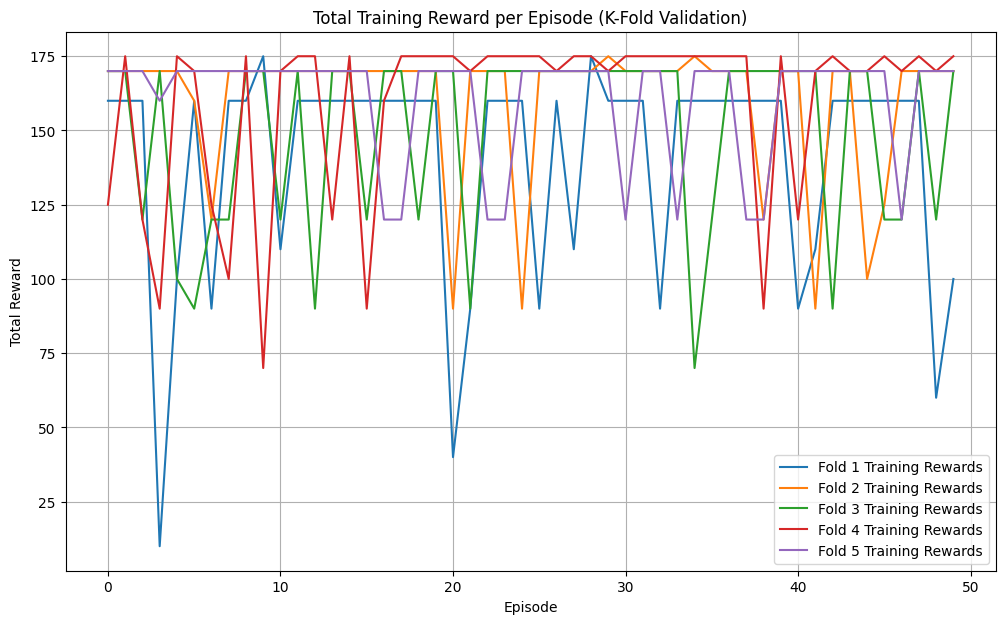

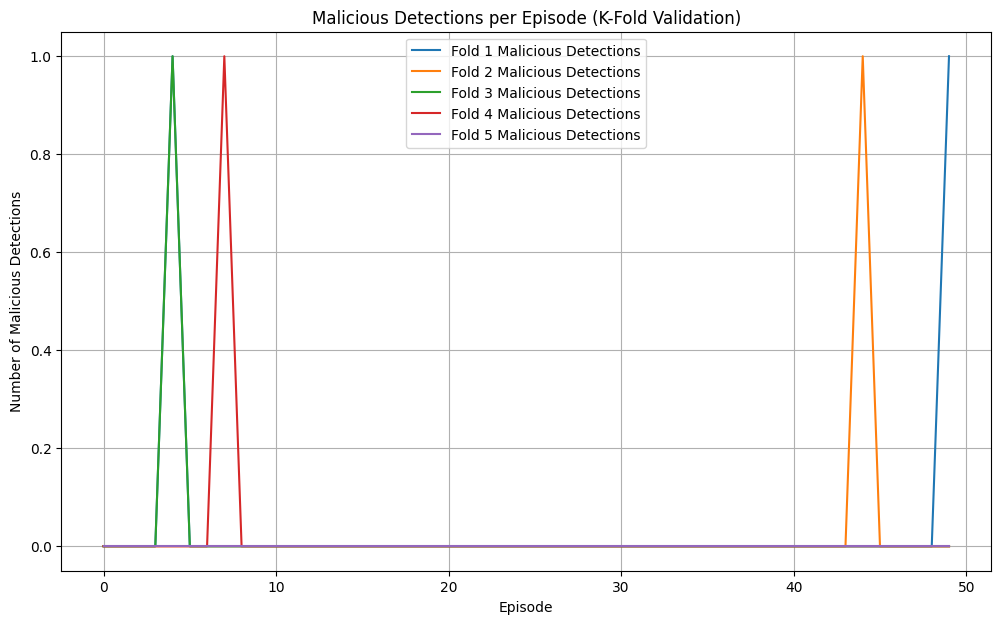

In [14]:
# --- Component 2: Advanced Reinforcement Learning Model with Comprehensive Features ---
import numpy as np
import random
import sys
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import KFold
import warnings

# Suppress all UserWarnings from sklearn
warnings.filterwarnings("ignore", category=UserWarning)

try:
    trained_classifier_model = trained_classifier_model
    selected_malicious_log = malicious_log_for_rl
    kmeans_model = kmeans_model_for_rl
    if selected_malicious_log is None or not hasattr(trained_classifier_model, 'predict_proba') or not hasattr(kmeans_model, 'predict'):
        raise ValueError("One or more required components are not available.")
except (NameError, ValueError) as e:
    print(f"Warning: Could not access classifier model or malicious log from Component 1. {e}. Using placeholders.")
    class DummyKMeans:
        def __init__(self, n_features_in=175):
            self.n_features_in_ = n_features_in
        def predict(self, x):
            means = np.mean(x, axis=1)
            return (means > 40).astype(int)
    class DummyClassifier:
        def __init__(self, n_features_in=176):
            self.n_features_in_ = n_features_in
        def predict_proba(self, x):
            mean_val = np.mean(x[:, :-1])
            if mean_val > 50:
                return np.array([[0.1, 0.9]])
            return np.array([[0.8, 0.2]])
    kmeans_model = DummyKMeans()
    trained_classifier_model = DummyClassifier()
    selected_malicious_log = np.random.randint(0, 150, size=175)
if selected_malicious_log is None or not hasattr(trained_classifier_model, 'predict_proba') or not hasattr(kmeans_model, 'predict'):
    print("Cannot run without a malicious log and models. Exiting.")
    sys.exit()
try:
    N_FEATURES_LOG = kmeans_model.n_features_in_
    N_FEATURES_CLASSIFIER = trained_classifier_model.n_features_in_
except AttributeError:
    print("Warning: Models do not have n_features_in_. Using fallback values.")
    N_FEATURES_LOG = selected_malicious_log.shape[0]
    N_FEATURES_CLASSIFIER = N_FEATURES_LOG + 1
print("--- Component 2: Advanced Reinforcement Learning Model ---")
def pad_log_to_features(log, target_features):
    """Pads a log array with zeros to match a target feature size."""
    if log.shape[0] < target_features:
        padding = target_features - log.shape[0]
        return np.pad(log, (0, padding), 'constant')
    return log[:target_features]
class AdvancedLinuxEnvironment:
    def __init__(self, initial_log, classifier, kmeans_model):
        self.classifier = classifier
        self.kmeans_model = kmeans_model
        self.log = pad_log_to_features(initial_log.copy(), N_FEATURES_LOG)
        self.state = self._get_state()
        self.deception_active = False
        self.is_malicious = True
    def _get_state(self):
        padded_log = pad_log_to_features(self.log.copy(), N_FEATURES_LOG)
        log_reshaped = padded_log.reshape(1, -1)
        cluster_prediction = self.kmeans_model.predict(log_reshaped)[0]
        mean_val = np.mean(self.log)
        if mean_val > 80:
            return f"high_activity_cluster_{cluster_prediction}"
        elif mean_val > 30:
            return f"medium_activity_cluster_{cluster_prediction}"
        else:
            return f"low_activity_cluster_{cluster_prediction}"
    def reset(self, initial_log):
        self.log = pad_log_to_features(initial_log.copy(), N_FEATURES_LOG)
        self.state = self._get_state()
        self.deception_active = False
        self.is_malicious = True
        return self.state
    def step(self, action_script):
        new_log = self.log.copy()
        action_reward = 0
        done = False
        if "rm" in action_script:
            new_log = np.zeros_like(new_log)
            action_reward = 150
            done = True
        elif "chown" in action_script:
            new_log = np.array([10]*len(new_log))
            action_reward = 120
            done = True
        elif "chmod" in action_script:
            new_log = np.array([20]*len(new_log))
            action_reward = 110
            done = True
        elif "deceive_ports" in action_script:
            new_log = np.random.randint(5, 20, size=len(new_log))
            action_reward = 90
            self.deception_active = True
            done = True
        elif "deceive_fs" in action_script:
            new_log = np.random.randint(10, 30, size=len(new_log))
            action_reward = 80
            self.deception_active = True
            done = True
        elif "deceive_service" in action_script:
            new_log = np.random.randint(15, 35, size=len(new_log))
            action_reward = 70
            self.deception_active = True
            done = True
        elif "echo" in action_script:
            new_log = np.random.randint(20, 40, size=len(new_log))
            action_reward = 40
            self.deception_active = True
            done = True
        elif any(cmd in action_script for cmd in ["systemctl", "firewall", "selinux", "kill", "ps", "netstat", "lsof", "auditctl", "fail2ban"]):
            new_log = np.array([10]*len(new_log))
            action_reward = 125
            done = True
        elif any(cmd in action_script for cmd in ["deceive_process", "fake_log", "deceive_user", "deceive_network", "deceive_config"]):
            new_log = np.random.randint(20, 40, size=len(new_log))
            action_reward = 85
            self.deception_active = True
            done = True
        else:
            action_reward = -100
            self.deception_active = False
        new_log = pad_log_to_features(new_log, N_FEATURES_LOG)
        log_reshaped = new_log.reshape(1, -1)
        cluster_prediction = self.kmeans_model.predict(log_reshaped)
        log_with_cluster = np.concatenate((log_reshaped, cluster_prediction.reshape(-1, 1)), axis=1)
        log_with_cluster = pad_log_to_features(log_with_cluster[0], N_FEATURES_CLASSIFIER).reshape(1, -1)
        classification_proba = self.classifier.predict_proba(log_with_cluster)[0, 1]
        self.is_malicious = (classification_proba > 0.5)
        if not self.is_malicious:
            classification_reward = 50
        else:
            classification_reward = -50
        total_reward = action_reward + classification_reward
        self.log = new_log
        new_state = self._get_state()
        return new_state, total_reward, done
class AdvancedNLPAgent:
    def __init__(self, actions):
        self.q_table = defaultdict(lambda: np.zeros(len(actions)))
        self.actions = actions
    def choose_action(self, state, exploration_rate, policy_type="epsilon-greedy"):
        if policy_type == "epsilon-greedy":
            if random.random() < exploration_rate:
                return random.randint(0, len(self.actions) - 1)
            else:
                return np.argmax(self.q_table[state])
        elif policy_type == "softmax":
            q_values = self.q_table[state]
            exp_q_values = np.exp(q_values - np.max(q_values))
            probabilities = exp_q_values / np.sum(exp_q_values)
            return np.random.choice(range(len(self.actions)), p=probabilities)
        else:
            raise ValueError("Invalid policy_type. Must be 'epsilon-greedy' or 'softmax'.")
    def update_policy(self, state, action_idx, reward, next_state, alpha, gamma):
        old_value = self.q_table[state][action_idx]
        next_max = np.max(self.q_table[next_state])
        self.q_table[state][action_idx] = old_value + alpha * (reward + gamma * next_max - old_value)
ACTION_SCRIPTS = [
    # --- Corrective Actions (50 scripts) ---
    "chown root:root /etc/shadow", "chmod 600 /etc/ssh/sshd_config", "rm -f /tmp/malicious.sh",
    "systemctl restart ssh", "iptables -A INPUT -p tcp --dport 22 -j DROP", "kill -9 $(pidof suspected_process)",
    "userdel -r compromised_user", "usermod -L compromised_user", "fail2ban-client ban --all",
    "auditctl -a always,exit -F arch=b64 -S open -F exit=-EPERM -k unauthorized_file_access",
    "semanage fcontext -a -t httpd_sys_content_t '/var/www(/.*)?'", "setsebool -P httpd_can_network_connect on",
    "netstat -tuln | grep 8080 | awk '{print $7}' | cut -d'/' -f1 | xargs kill",
    "lsof -iTCP -sTCP:LISTEN -P", "find / -name '*malware*' -delete", "clamscan -r / --move=/quarantine",
    "ufw reset", "ufw enable", "ufw deny incoming", "ufw allow 22/tcp",
    "rsync -avz /backup/files/ /", "iptables -P FORWARD DROP", "iptables -F",
    "echo 1 > /proc/sys/net/ipv4/tcp_syncookies", "sysctl -p", "route del default gw 192.168.1.1",
    "crontab -r", "find /tmp -type f -mtime +1 -delete", "truncate -s 0 /var/log/auth.log",
    "restorecon -R /var/www/html", "sed -i 's/^PermitRootLogin yes/PermitRootLogin no/' /etc/ssh/sshd_config",
    "grep 'failed password' /var/log/auth.log | awk '{print $11}' | sort | uniq -c | sort -nr",
    "chattr +i /etc/passwd", "chattr +a /var/log/audit", "e2fsck -f /dev/sda1",
    "fsck -y /dev/sda1", "fuser -k 8080/tcp", "killall -9 suspicious_process",
    "usermod -s /sbin/nologin compromised_user", "passwd -d compromised_user", "groupdel malicious_group",
    "rm -rf /root/.ssh/authorized_keys", "service sshd restart", "service httpd stop",
    "systemctl stop compromised_service", "systemctl disable compromised_service", "yum check-update",
    "apt-get update", "apt-get upgrade -y", "yum update -y",
    "dpkg -P malicious_package", "yum erase malicious_package", "find / -perm /6000",
    "find /var/www -name '*.php' -type f -exec grep -l -E 'eval\\(|base64_decode' {} \\;",
    "grep -r 'suspicious_ip' /var/log/apache2/", "find / -type f -name '.*' -ls",
    "ip route del 10.0.0.0/8", "iptables -A INPUT -s 1.2.3.4 -j DROP",
    # --- Deceptive Actions (50 scripts) ---
    "deceive_ports", "deceive_fs", "deceive_service", "echo 'System clean' > /var/log/fake_scan.log",
    "deceive_process_list", "deceive_network_traffic", "deceive_user_accounts", "deceive_file_permissions",
    "deceive_running_services", "deceive_configuration_files", "deceive_log_history",
    "touch -a -m -t 201010101010.10 /tmp/.malicious.sh", "iptables -A INPUT -j ACCEPT", "iptables -A OUTPUT -j ACCEPT",
    "service fake_service start", "mkdir /var/log/old_logs", "mv /var/log/auth.log /var/log/old_logs/auth.log.bak",
    "echo 'localhost' > /etc/hosts", "echo '127.0.0.1 www.example.com' >> /etc/hosts",
    "ln -s /dev/null /var/log/syslog", "echo 'malicious_user ALL=(ALL) NOPASSWD: ALL' > /etc/sudoers.d/fake_sudo",
    "cp /bin/ls /tmp/ls", "chmod u+s /tmp/ls", "cp /etc/passwd /tmp/passwd",
    "chmod 777 /var/www/html/", "chown nobody:nobody /var/www/html/",
    "echo 'HTTP/1.1 200 OK' > /var/www/html/index.php", "echo 'root:x:0:0:root:/root:/bin/bash' > /etc/shadow",
    "touch /var/tmp/.ssh_dir", "touch -t 200501010101.01 /etc/passwd", "touch /dev/null",
    "ln -s /dev/null /var/log/secure", "echo 'This is a test log.' > /var/log/secure",
    "mkdir -p /home/legit_user/.ssh", "touch /home/legit_user/.ssh/authorized_keys",
    "cp /usr/bin/ssh /tmp/ssh_wrapper", "echo '#!/bin/sh' > /tmp/wrapper.sh", "chmod +x /tmp/wrapper.sh",
    "echo 'alias ls=\"ls -la\"' > ~/.bashrc", "echo 'alias rm=\"rm -i\"' > ~/.bashrc",
    "echo 'alias netstat=\"ss\"' > ~/.bashrc", "echo 'alias ps=\"ps -fe\"' > ~/.bashrc",
    "echo 'alias df=\"df -h\"' > ~/.bashrc", "echo 'alias du=\"du -sh\"' > ~/.bashrc",
    "cp /etc/cron.d/anacron /etc/cron.d/anacron.bak", "chmod 400 /etc/sudoers",
    "chown root:root /etc/sudoers", "touch /var/www/.htaccess",
    "echo 'deny from all' > /var/www/.htaccess", "echo 'order allow,deny' >> /var/www/.htaccess",
    "echo 'Allow from 127.0.0.1' >> /var/www/.htaccess", "echo 'RewriteEngine On' > /var/www/html/.htaccess",
    "echo 'RewriteRule .* - [F]' >> /var/www/html/.htaccess", "echo 'Header set X-Frame-Options DENY' > /etc/apache2/conf-available/security.conf",
    "echo 'ServerSignature Off' >> /etc/apache2/conf-available/security.conf", "echo 'ServerTokens Prod' >> /etc/apache2/conf-available/security.conf",
    "echo 'X-XSS-Protection \"1; mode=block\"' >> /etc/apache2/conf-available/security.conf",
]
def run_kfold_validation(n_splits=5):
    """
    Performs K-Fold Cross-Validation on the action scripts.
    The agent is trained on a subset of actions and tested on a held-out set.
    """
    print(f"\n--- Starting {n_splits}-Fold Cross-Validation on Action Scripts ---")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # Create a dummy log dataset for the environment to reset to, since the focus is on action scripts
    log_dataset = [np.random.randint(50, 150, size=N_FEATURES_LOG) for _ in range(50)]

    for i, (train_index, test_index) in enumerate(kf.split(ACTION_SCRIPTS)):
        print(f"\n--- Fold {i+1}/{n_splits} ---")

        # Split actions for this fold
        train_actions = [ACTION_SCRIPTS[j] for j in train_index]
        test_actions = [ACTION_SCRIPTS[j] for j in test_index]

        # Train the agent on the training set of actions
        agent = AdvancedNLPAgent(train_actions)
        env = AdvancedLinuxEnvironment(selected_malicious_log, trained_classifier_model, kmeans_model)

        EPISODES = 50
        ALPHA = 0.1
        GAMMA = 0.9
        EPSILON = 0.2
        POLICY_TYPE = "epsilon-greedy"

        train_rewards = []
        train_malicious_flags = []

        for episode in range(EPISODES):
            initial_log = random.choice(log_dataset)
            state = env.reset(initial_log)
            done = False
            total_reward = 0
            malicious_count = 0

            while not done:
                action_idx = agent.choose_action(state, EPSILON, policy_type=POLICY_TYPE)
                next_state, reward, done = env.step(train_actions[action_idx])
                agent.update_policy(state, action_idx, reward, next_state, ALPHA, GAMMA)
                state = next_state
                total_reward += reward
                if env.is_malicious:
                    malicious_count += 1
            train_rewards.append(total_reward)
            train_malicious_flags.append(malicious_count)

        # Evaluate the trained agent on the test set of actions
        test_rewards = []
        test_malicious_flags = []

        for action_script in test_actions:
            initial_log = random.choice(log_dataset)
            state = env.reset(initial_log)
            next_state, reward, done = env.step(action_script)
            test_rewards.append(reward)
            test_malicious_flags.append(1 if env.is_malicious else 0)

        avg_test_reward = np.mean(test_rewards)
        avg_test_malicious_rate = np.mean(test_malicious_flags)

        print(f"  Fold {i+1} Training Complete. Average Test Reward: {avg_test_reward:.2f}, Malicious Rate: {avg_test_malicious_rate:.2f}")

        # Print the Q-table for the current fold
        print("\n--- Q-Table for Fold {} ---".format(i+1))
        q_table = agent.q_table
        actions = agent.actions
        states = sorted(q_table.keys())
        print(f"{'State':<30} | {' | '.join(f'{action:<20}' for action in actions[:5])} ...")
        print("-" * (30 + 3 + len(actions[:5]) * 23))
        for state in states:
            q_values = q_table[state]
            q_value_str = ' | '.join(f'{q:.2f}' for q in q_values[:5])
            print(f"{state:<30} | {q_value_str} ...")

        fold_results.append({
            'train_rewards': train_rewards,
            'train_malicious_flags': train_malicious_flags,
            'test_reward': avg_test_reward,
            'test_malicious_rate': avg_test_malicious_rate,
            'q_table': agent.q_table,
            'actions': train_actions
        })
    return fold_results

kfold_results = run_kfold_validation(n_splits=5)
print("\n--- Generating Visual Comparisons ---")

# Training Rewards Plot
plt.figure(figsize=(12, 7))
for i, result in enumerate(kfold_results):
    plt.plot(result['train_rewards'], label=f'Fold {i+1} Training Rewards')
plt.title('Total Training Reward per Episode (K-Fold Validation)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

# Training Malicious Flags Plot
plt.figure(figsize=(12, 7))
for i, result in enumerate(kfold_results):
    plt.plot(result['train_malicious_flags'], label=f'Fold {i+1} Malicious Detections')
plt.title('Malicious Detections per Episode (K-Fold Validation)')
plt.xlabel('Episode')
plt.ylabel('Number of Malicious Detections')
plt.legend()
plt.grid(True)
plt.show()

# Average Test Metrics Plot
test_rewards = [res['test_reward'] for res in kfold_results]
test_malicious_rates = [res['test_malicious_rate'] for res in kfold_results]
